# Chunk 27 — Stratified Re-Audit: Full L0 → κ=1.0 → κ=1.5 → κ=2.0 Progression

**Project:** GATv2 Surrogate Model for Pixelated Microstrip Patch Antennas  
**Goal:** Produce the complete, auditable evidence table for the thesis: the full depth-bias
progression from the original un-reweighted MSE baseline (L0) through the pre-registered
asymmetric loss selection (κ=1.5) to the documented cap-override candidate (κ=2.0).

### Arm Definitions (fixed — do not add, drop, or rename)
| Arm | Description | 2000-sample checkpoint | 4000-sample checkpoint |
|-----|-------------|----------------------|----------------------|
| L0 | Original un-reweighted MSE baseline | `ch22_L0_seed{s}.pt` | **None** (never retrained at 4000) |
| κ=1.0 (L2) | Confirmed stable win from seed-stability study | `ch22_L2_seed{s}.pt` | `asym_scaleup_k1.0_seed{s}.pt` |
| κ=1.5 | Pre-registered selection at 4000 samples | `asym_k1.5_seed{s}.pt` | `asym_scaleup_k1.5_seed{s}.pt` |
| κ=2.0 | **Documented override** of 15% MAE cap (15.13% ± 2.11%) | `asym_k2.0_seed{s}.pt` | `asym_scaleup_k2.0_seed{s}.pt` |

### Primary vs Secondary Comparison
- **PRIMARY:** 4-arm comparison at **2000 samples** — the ONLY scale where all 4 arms exist.
- **SECONDARY:** 3-arm comparison at **4000 samples** (no L0) — shows scale-robustness of the asymmetric-loss effect.

### GPU Note
GPU optional — evaluation-only (forward passes). ~30 min on T4, ~1.5–2 hrs on CPU.

In [1]:
# Install required packages
# Use prebuilt wheels for torch-scatter/torch-sparse to avoid slow source builds
import torch
tv = torch.__version__.split('+')[0]   # e.g. '2.6.0'
cv = torch.version.cuda.replace('.', '')  # e.g. '124'
whl = f'https://data.pyg.org/whl/torch-{tv}+cu{cv}.html'
print(f'PyG wheel index: {whl}')
!pip install -q torch-scatter torch-sparse -f {whl}
!pip install -q torch-geometric scipy pandas matplotlib seaborn tqdm pyarrow fastparquet scikit-learn

PyG wheel index: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.1 MB/s eta 0:00:00


In [2]:
# Clone the repository and add src to sys.path
import os
import sys

REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull

if f'{REPO_ROOT}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_ROOT}/src')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (360/360), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 360 (delta 197), reused 300 (delta 139), pack-reused 0 (from 0)
Receiving objects: 100% (360/360), 9.58 MiB | 15.52 MiB/s, done.
Resolving deltas: 100% (197/197), done.


In [3]:
# Mount Google Drive and set data paths
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA = '/content/drive/MyDrive/antenna_dataset'

# Create necessary directories in DATA_ROOT
os.makedirs(f'{DATA_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/figures', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints/scaleup', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints/tradeoff', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints/stability', exist_ok=True)

Mounted at /content/drive


---
## Cell A — Load Everything, No Retraining

**Purpose:**
1. Define model architecture (`AntennaGNN`) and dataset (`FinetuneDataset`) — verbatim from Chunk 26.
2. Load normalization stats, validation split, set `TEST_INDICES_LOADED = False`.
3. Stage validation data to local SSD with tar-cache for fast I/O.
4. Load all checkpoints per the corrected availability mapping:
   - L0: 2000 samples only (5 seeds)
   - κ=1.0: 2000 + 4000 (10 checkpoints)
   - κ=1.5: 2000 + 4000 (10 checkpoints)
   - κ=2.0: 2000 + 4000 (10 checkpoints)
   - Total expected: 35 checkpoints
5. Print checkpoint-availability table before proceeding.

In [4]:
# ==========================================================================
# CELL A — Load Everything, No Retraining
# ==========================================================================

import json
import hashlib
import shutil
import time
import copy
import os
import tarfile
import concurrent.futures
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, OrderedDict
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score)
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Disable TF32 for numerical consistency
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
print('TF32 disabled')

SEEDS = [42, 43, 44, 45, 46]

# ── FinetuneDataset — verbatim from Chunk 13/22/26 ──
class FinetuneDataset(TorchDataset):
    """Fine-tune graph dataset with mandatory z-score normalization at load."""

    def __init__(self, indices, processed_dir_base, s11_mean, s11_std):
        assert s11_mean is not None, 'FinetuneDataset requires s11_mean (got None)'
        assert s11_std is not None,  'FinetuneDataset requires s11_std (got None)'
        self.indices = indices
        self.processed_dir_base = processed_dir_base
        self.s11_mean = s11_mean   # (201,) tensor
        self.s11_std  = s11_std    # (201,) tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        grid_size, local_idx = self.indices[idx]
        path = f'{self.processed_dir_base}/{grid_size}x{grid_size}/sample_{local_idx}.pt'
        data = torch.load(path, weights_only=False)

        # Preserve raw dB target, then z-score
        data.y_raw = data.y.clone()                              # (1, 201) raw dB
        data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)  # (1, 201) normalized

        return data


# ── Model Architecture — verbatim from model.py / Chunk 26 ──
class GATv2Block(nn.Module):
    def __init__(self, in_channels, out_channels, heads, edge_dim, dropout=0.0):
        super().__init__()
        self.conv = GATv2Conv(
            in_channels, out_channels // heads,
            heads=heads, edge_dim=edge_dim,
            concat=True, dropout=dropout
        )
        self.norm = nn.LayerNorm(out_channels)
        self.residual_proj = (nn.Linear(in_channels, out_channels)
                              if in_channels != out_channels else nn.Identity())
        self.act = nn.ReLU()

    def forward(self, x, edge_index, edge_attr):
        out = self.conv(x, edge_index, edge_attr=edge_attr)
        out = self.norm(out)
        out = self.act(out + self.residual_proj(x))
        return out


class AntennaGNN(nn.Module):
    def __init__(self, node_feat_dim=5, edge_feat_dim=2,
                 hidden_dim=128, heads=8, edge_dim=16,
                 num_blocks=4, output_dim=201,
                 conv_dropout=0.10, mlp_dropout=0.10,
                 dropout_from_block=2):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.edge_proj  = nn.Linear(edge_feat_dim, edge_dim)

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            block_dropout = conv_dropout if i >= dropout_from_block else 0.0
            self.blocks.append(nn.ModuleList([
                GATv2Block(hidden_dim, hidden_dim, heads, edge_dim, dropout=block_dropout),
                GATv2Block(hidden_dim, hidden_dim, heads, edge_dim, dropout=block_dropout),
            ]))

        self.readout_proj = nn.Linear(hidden_dim * 2, 256)
        self.output_mlp = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.LayerNorm(512),
            nn.Linear(512, output_dim)
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        for block in self.blocks:
            for layer in block:
                x = layer(x, edge_index, edge_attr)

        # Metal-only pooling
        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        # Virtual node embedding
        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)
        out = self.readout_proj(combined)
        out = self.output_mlp(out)
        return out


# ── Frequency axis ──
freq_axis = np.linspace(1.0, 4.0, 201)

# ── Load normalization statistics ──
s11_mean_np = np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')
s11_std_np  = np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')
s11_mean_cpu = torch.tensor(s11_mean_np, dtype=torch.float32)
s11_std_cpu  = torch.tensor(s11_std_np,  dtype=torch.float32)
s11_mean_dev = s11_mean_cpu.to(device)
s11_std_dev  = s11_std_cpu.to(device)

# ── Load splits ──
with open(f'{DATA_ROOT}/splits/finetune_val_indices.json') as f:
    val_indices = json.load(f)

TEST_INDICES_LOADED = False
print(f'Validation indices: {len(val_indices)}')

# ── Local disk staging for fast I/O ──
processed_dir = f'{DATA_ROOT}/data/processed_finetune'
STAGE_LOCALLY = True
staging_mode = 'Drive-direct'

if STAGE_LOCALLY:
    drive_dir = f'{DATA_ROOT}/data/processed_finetune'
    local_dir = '/content/processed_finetune'
    try:
        needed = set()
        for gs, li in val_indices:
            needed.add((gs, li))
        needed_sorted = sorted(needed)
        n_need = len(needed_sorted)
        print(f'Staging {n_need} unique validation files to local disk...')

        probe_idx = list(needed)[:20]
        probe_sizes = []
        for gs, li in probe_idx:
            p = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
            if os.path.exists(p):
                probe_sizes.append(os.path.getsize(p))
        est_gb = (sum(probe_sizes) / len(probe_sizes)) * n_need / 1e9 if probe_sizes else 0
        free_gb = shutil.disk_usage('/content').free / 1e9
        print(f'~{est_gb:.2f} GB estimated, {free_gb:.1f} GB free on /content')
        assert free_gb > est_gb * 1.5, 'not enough local disk space'

        os.makedirs(local_dir, exist_ok=True)
        needed_hash = hashlib.sha256(
            json.dumps(needed_sorted).encode()).hexdigest()[:16]
        archive_path = f'{DATA_ROOT}/data/_stage_cache/{needed_hash}.tar'

        if os.path.exists(archive_path):
            print(f'Found cached archive for this exact file set: {archive_path}')
            t0 = time.time()
            with tarfile.open(archive_path, 'r') as tf:
                tf.extractall(local_dir)
            print(f'Extracted cached archive in {time.time() - t0:.1f} s')
            staging_mode = 'cache archive extracted'
        else:
            def _copy_one(item):
                gs, li = item
                src_path = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
                dst_dir_l = f'{local_dir}/{gs}x{gs}'
                dst_path = f'{dst_dir_l}/sample_{li}.pt'
                if os.path.exists(dst_path):
                    return False
                os.makedirs(dst_dir_l, exist_ok=True)
                for attempt in range(2):
                    try:
                        shutil.copy2(src_path, dst_path)
                        return True
                    except OSError:
                        if attempt == 0:
                            time.sleep(0.5)
                        else:
                            raise

            t0 = time.time()
            n_copied = 0
            with concurrent.futures.ThreadPoolExecutor(max_workers=16) as ex:
                futures = [ex.submit(_copy_one, item) for item in needed_sorted]
                for fut in tqdm(concurrent.futures.as_completed(futures),
                                total=len(futures), desc='Staging needed files'):
                    if fut.result():
                        n_copied += 1
            print(f'Staged {n_copied} new files in {time.time() - t0:.1f} s')

            # Build cache archive for next time
            try:
                os.makedirs(os.path.dirname(archive_path), exist_ok=True)
                t0_arch = time.time()
                with tarfile.open(archive_path, 'w') as tf:
                    for gs, li in needed_sorted:
                        src_f = f'{local_dir}/{gs}x{gs}/sample_{li}.pt'
                        if os.path.exists(src_f):
                            tf.add(src_f, arcname=f'{gs}x{gs}/sample_{li}.pt')
                print(f'Wrote staging cache archive in {time.time() - t0_arch:.1f} s')
            except Exception as arc_e:
                print(f'Warning: failed to write staging cache archive ({arc_e})')

            staging_mode = 'parallel fresh staging + cache built'

        processed_dir = local_dir
    except Exception as e:
        staging_mode = f'fallback to Drive-direct ({type(e).__name__}: {e})'
        print(f'Staging skipped ({type(e).__name__}: {e}); continuing from Drive')

print(f'[STAGING SUMMARY] Mode: {staging_mode} | Processed dir: {processed_dir}')

# ── Dataset & DataLoader ──
val_ds = FinetuneDataset(val_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

# ── Canonical Normalization Guard ──
probe_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
ys, yr = [], []
for b in tqdm(probe_loader, desc='Normalization Guard'):
    ys.append(b.y.view(-1, 201))
    yr.append(b.y_raw.view(-1, 201))
all_y, all_raw = torch.cat(ys), torch.cat(yr)
assert not torch.allclose(all_y, all_raw), 'y == y_raw — normalization is a no-op'
recon = all_y * s11_std_cpu + s11_mean_cpu
maxdiff = (recon - all_raw).abs().max().item()
assert maxdiff < 1e-3, f'round trip FAILED: max diff {maxdiff:.6f}'
print(f'[PASS] Normalization guard passed (round trip max diff: {maxdiff:.2e})')
del probe_loader, ys, yr, all_y, all_raw, recon


# ═══════════════════════════════════════════════════════════════════════════════
# CHECKPOINT AVAILABILITY MAPPING (corrected — L0 at 2000 ONLY)
# ═══════════════════════════════════════════════════════════════════════════════

ARM_CHECKPOINT_MAP = OrderedDict()

# L0: 2000 samples ONLY
ARM_CHECKPOINT_MAP[('L0', 2000)] = f'{DATA_ROOT}/checkpoints/stability/ch22_L0_seed{{seed}}.pt'

# kappa=1.0 (L2): BOTH scales
ARM_CHECKPOINT_MAP[('kappa=1.0', 2000)] = f'{DATA_ROOT}/checkpoints/stability/ch22_L2_seed{{seed}}.pt'
ARM_CHECKPOINT_MAP[('kappa=1.0', 4000)] = f'{DATA_ROOT}/checkpoints/scaleup/asym_scaleup_k1.0_seed{{seed}}.pt'

# kappa=1.5: BOTH scales
ARM_CHECKPOINT_MAP[('kappa=1.5', 2000)] = f'{DATA_ROOT}/checkpoints/tradeoff/asym_k1.5_seed{{seed}}.pt'
ARM_CHECKPOINT_MAP[('kappa=1.5', 4000)] = f'{DATA_ROOT}/checkpoints/scaleup/asym_scaleup_k1.5_seed{{seed}}.pt'

# kappa=2.0: BOTH scales (documented cap override)
ARM_CHECKPOINT_MAP[('kappa=2.0', 2000)] = f'{DATA_ROOT}/checkpoints/tradeoff/asym_k2.0_seed{{seed}}.pt'
ARM_CHECKPOINT_MAP[('kappa=2.0', 4000)] = f'{DATA_ROOT}/checkpoints/scaleup/asym_scaleup_k2.0_seed{{seed}}.pt'

ARM_LABELS = ['L0', 'kappa=1.0', 'kappa=1.5', 'kappa=2.0']

# ── Print checkpoint-availability table ──
print('\n' + '=' * 95)
print('CHECKPOINT AVAILABILITY TABLE')
print('=' * 95)

header = f'{"Arm":<12} {"Samples":>7} {"Seed 42":>8} {"Seed 43":>8} {"Seed 44":>8} {"Seed 45":>8} {"Seed 46":>8}  Notes'
print(header)
print('-' * len(header) + '-' * 20)

loaded_checkpoints = {}   # (arm, sample_size, seed) -> state_dict
availability = {}         # (arm, sample_size, seed) -> bool
n_expected = 0
n_found = 0
missing_list = []

for (arm, ss), path_template in ARM_CHECKPOINT_MAP.items():
    row_vals = []
    note = ''
    if arm == 'L0' and ss == 2000:
        note = '(L0 at 2000 ONLY — never retrained at 4000)'
    elif arm == 'kappa=2.0':
        note = '(cap override: 15.13% ± 2.11% vs 15% cap)'

    for seed in SEEDS:
        n_expected += 1
        p = path_template.format(seed=seed)
        found = os.path.exists(p) and os.path.getsize(p) > 0
        availability[(arm, ss, seed)] = found
        if found:
            n_found += 1
            row_vals.append('  FOUND')
            # Load the checkpoint
            ckpt = torch.load(p, map_location='cpu', weights_only=False)
            loaded_checkpoints[(arm, ss, seed)] = ckpt
            del ckpt
        else:
            row_vals.append('MISSING')
            missing_list.append(f'{arm} @ {ss} samples, seed={seed}: {p}')

    print(f'{arm:<12} {ss:>7} {"  ".join(row_vals)}  {note}')

# Print the deliberate gap
print()
print(f'NOTE: L0 has no 4000-sample row — this is not a missing checkpoint but a')
print(f'      never-trained arm. The PRIMARY 4-arm comparison uses 2000-sample scale.')
print()

print(f'Expected: {n_expected} checkpoints, Found: {n_found}')

if missing_list:
    print(f'\n\u26a0 MISSING CHECKPOINTS ({len(missing_list)}):')
    for m in missing_list:
        print(f'  - {m}')
    print('Proceeding with available checkpoints only.')
else:
    print('[PASS] All expected checkpoints found and loaded.')

print(f'\n[PASS] Cell A complete. {n_found}/{n_expected} checkpoints loaded.')

Device: cuda
TF32 disabled
Validation indices: 1496
Staging 1496 unique validation files to local disk...
~0.42 GB estimated, 70.0 GB free on /content
Found cached archive for this exact file set: /content/drive/MyDrive/antenna_gnn/data/_stage_cache/0cd92b0269b27cb8.tar


/tmp/ipykernel_1986/2865227049.py:194: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(local_dir)


Extracted cached archive in 5.0 s
[STAGING SUMMARY] Mode: cache archive extracted | Processed dir: /content/processed_finetune


Normalization Guard:   0%|          | 0/24 [00:00<?, ?it/s]

[PASS] Normalization guard passed (round trip max diff: 1.91e-06)

CHECKPOINT AVAILABILITY TABLE
Arm          Samples  Seed 42  Seed 43  Seed 44  Seed 45  Seed 46  Notes
--------------------------------------------------------------------------------------------
L0              2000   FOUND    FOUND    FOUND    FOUND    FOUND  (L0 at 2000 ONLY — never retrained at 4000)
kappa=1.0       2000   FOUND    FOUND    FOUND    FOUND    FOUND  
kappa=1.0       4000   FOUND    FOUND    FOUND    FOUND    FOUND  
kappa=1.5       2000   FOUND    FOUND    FOUND    FOUND    FOUND  
kappa=1.5       4000   FOUND    FOUND    FOUND    FOUND    FOUND  
kappa=2.0       2000   FOUND    FOUND    FOUND    FOUND    FOUND  (cap override: 15.13% ± 2.11% vs 15% cap)
kappa=2.0       4000   FOUND    FOUND    FOUND    FOUND    FOUND  (cap override: 15.13% ± 2.11% vs 15% cap)

NOTE: L0 has no 4000-sample row — this is not a missing checkpoint but a
      never-trained arm. The PRIMARY 4-arm comparison uses 2000-sampl

---
## Cell B — Full Stratified FNR/FPR Audit (All Available Arms × Seeds × Scales)

**Purpose:** Reproduce Chunk 22 Cell I's exact bin definitions and Cell J's
fixed-vs-own-threshold comparison for every loaded checkpoint. For each arm/scale,
report mean ± std across 5 seeds for pooled AUROC, 55×55 AUROC, FNR per bin at
fixed −10 dB, FPR on non-functioning at each arm's own τ*_bal.

**Key:** Per-sample DataFrames stored in memory for reuse in Cell B.5 — no re-inference there.

Saves `DATA_ROOT/artifacts/full_progression_audit.csv`.

In [5]:
# ==========================================================================
# CELL B — Full Stratified FNR/FPR Audit
# ==========================================================================

# ── Exact bin definitions (shallow-to-deep-tail-last, single ordered triples) ──
BIN_DEFS = [
    (-15.0, -10.0, '(-15,-10]'),    # shallow — must stay first
    (-20.0, -15.0, '(-20,-15]'),    # moderate
    (-30.0, -20.0, '(-30,-20]'),    # deep
    (-np.inf, -30.0, '(-inf,-30]'), # tail — must stay last (n<15, excluded from REPORTABLE_BINS)
]


def assign_bin(val):
    """Assign a true_min_db value to a depth bin label."""
    for lo, hi, label in BIN_DEFS:
        if lo < val <= hi:
            return label
    return None  # e.g. non-functioning (val > -10), not binned


BIN_LABELS = [label for _, _, label in BIN_DEFS]
REPORTABLE_BINS = [label for _, _, label in BIN_DEFS[:3]]  # excludes tail

# ── Pre-Execution Audit: Validate BIN_DEFS on validation set ──
print('Running pre-execution sample count audit on validation dataset...')
CANONICAL_COUNTS = {'(-15,-10]': 536, '(-20,-15]': 216, '(-30,-20]': 152, '(-inf,-30]': 13}
val_bin_counts = {label: 0 for label in BIN_LABELS}
val_func_count = 0

for batch in val_loader:
    true_db = batch.y_raw.squeeze(1)
    true_min_np = true_db.min(dim=-1).values.cpu().numpy()
    is_func_np = batch.is_functioning.cpu().numpy() if isinstance(batch.is_functioning, torch.Tensor) else np.array(batch.is_functioning)

    for t_min, is_f in zip(true_min_np, is_func_np):
        if is_f:
            val_func_count += 1
            b_label = assign_bin(float(t_min))
            if b_label in val_bin_counts:
                val_bin_counts[b_label] += 1

print(f'  Total functioning validation samples: {val_func_count} (expected ~917)')
print('  Bin sample counts:')
for bl, exp in CANONICAL_COUNTS.items():
    act = val_bin_counts[bl]
    diff = abs(act - exp)
    status = 'PASS' if diff <= 5 else 'FAIL'
    print(f'    {bl:<15}: actual = {act:>4}, expected = {exp:>4} (delta = {act-exp:+d}) [{status}]')
    assert status == 'PASS', f'FATAL PRE-EXECUTION AUDIT FAIL: Bin {bl} count {act} differs from canonical {exp} by {diff} > 5'

print('[PASS] Pre-execution BIN_DEFS sample count audit passed successfully.\n')

def evaluate_model(model_eval, loader):
    """Run forward pass, collect per-sample records DataFrame."""
    model_eval.eval()
    records = []
    pos = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred_norm = model_eval(batch)
            pred_db = pred_norm * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)
            pred_np = pred_db.detach().cpu().numpy()
            true_np = true_db.detach().cpu().numpy()

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()
            is_func_list = batch.is_functioning
            if isinstance(is_func_list, torch.Tensor):
                is_func_list = is_func_list.tolist()

            for i in range(pred_np.shape[0]):
                records.append({
                    'test_idx': pos,
                    'grid': int(grids[i]),
                    'true_min_db': float(true_np[i].min()),
                    'pred_min_db': float(pred_np[i].min()),
                    'is_functioning': bool(is_func_list[i]),
                    's11_mae': float(np.abs(pred_np[i] - true_np[i]).mean()),
                })
                pos += 1

    df = pd.DataFrame(records)
    return df


def compute_audit_metrics(df):
    """Compute full audit metrics from a per-sample DataFrame."""
    labels = df['is_functioning'].astype(int).values
    scores = -df['pred_min_db'].values

    pooled_auroc = float(roc_auc_score(labels, scores))
    df55 = df[df['grid'] == 55]
    if len(df55) > 0 and df55['is_functioning'].nunique() > 1:
        g55_auroc = float(roc_auc_score(
            df55['is_functioning'].astype(int).values,
            -df55['pred_min_db'].values))
    else:
        g55_auroc = float('nan')

    pooled_s11_mae = float(df['s11_mae'].mean())

    func_df = df[df['is_functioning']].copy()
    func_df['depth_bin'] = func_df['true_min_db'].apply(assign_bin)

    bin_counts, bin_fn, bin_fnr = {}, {}, {}
    for bl in BIN_LABELS:
        sub_b = func_df[func_df['depth_bin'] == bl]
        n_b = len(sub_b)
        bin_counts[bl] = n_b
        if n_b > 0:
            fn_b = int((sub_b['pred_min_db'] >= -10.0).sum())
            bin_fn[bl] = fn_b
            bin_fnr[bl] = float(fn_b / n_b)
        else:
            bin_fn[bl] = 0
            bin_fnr[bl] = float('nan')

    total_fn_deep = sum(bin_fn[b] for b in REPORTABLE_BINS)
    total_n_deep  = sum(bin_counts[b] for b in REPORTABLE_BINS)
    fnr_deep_pooled = float(total_fn_deep / total_n_deep) if total_n_deep > 0 else float('nan')

    # Sweep tau*_bal
    best_tau = -10.0
    best_ba = -1.0
    for tau in np.arange(-5.0, -13.25, -0.25):
        preds = (df['pred_min_db'].values < tau).astype(int)
        ba = balanced_accuracy_score(labels, preds)
        if ba > best_ba:
            best_ba = ba
            best_tau = float(tau)

    # FPR on non-functioning at own tau*_bal
    nonfunc = df[~df['is_functioning']]
    n_nf = len(nonfunc)
    if n_nf > 0:
        fpr_at_tau = float((nonfunc['pred_min_db'] < best_tau).sum() / n_nf)
    else:
        fpr_at_tau = float('nan')

    return {
        'pooled_auroc': pooled_auroc,
        'g55_auroc': g55_auroc,
        'pooled_s11_mae': pooled_s11_mae,
        'fnr_deep_pooled': fnr_deep_pooled,
        'fnr_15_10': bin_fnr['(-15,-10]'],
        'fnr_20_15': bin_fnr['(-20,-15]'],
        'fnr_30_20': bin_fnr['(-30,-20]'],
        'fnr_inf_30': bin_fnr['(-inf,-30]'],
        'n_15_10': bin_counts['(-15,-10]'],
        'n_20_15': bin_counts['(-20,-15]'],
        'n_30_20': bin_counts['(-30,-20]'],
        'n_inf_30': bin_counts['(-inf,-30]'],
        'tau_star_bal': best_tau,
        'fpr_at_tau': fpr_at_tau,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# RUN EVALUATION FOR ALL LOADED CHECKPOINTS
# ═══════════════════════════════════════════════════════════════════════════════

all_persample_dfs = {}   # (arm, sample_size, seed) -> per-sample DataFrame
all_audit_metrics = []   # list of dicts for the audit CSV

total_evals = sum(1 for k, v in availability.items() if v)
eval_counter = 0

for (arm, ss), path_template in ARM_CHECKPOINT_MAP.items():
    for seed in SEEDS:
        if not availability.get((arm, ss, seed), False):
            continue

        eval_counter += 1
        print(f'\n[{eval_counter}/{total_evals}] Evaluating {arm} @ {ss} samples, seed={seed}...')

        # Load model
        model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201)
        state = loaded_checkpoints[(arm, ss, seed)]
        if isinstance(state, dict) and 'model_state' in state:
            model.load_state_dict(state['model_state'], strict=True)
        else:
            model.load_state_dict(state, strict=True)
        model = model.to(device)

        df_eval = evaluate_model(model, val_loader)
        metrics = compute_audit_metrics(df_eval)

        all_persample_dfs[(arm, ss, seed)] = df_eval

        all_audit_metrics.append({
            'arm': arm,
            'sample_size': ss,
            'seed': seed,
            'is_primary_comparison': (ss == 2000),
            **metrics,
        })

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f'\n{"=" * 90}')
print(f'Completed {eval_counter} evaluations.')

# ── Build audit DataFrame ──
df_audit = pd.DataFrame(all_audit_metrics)

# ── Aggregate per (arm, sample_size): mean ± std across seeds ──
print('\n' + '=' * 110)
print('AGGREGATED AUDIT RESULTS (mean ± std across 5 seeds)')
print('=' * 110)

agg_rows = []
for (arm, ss), grp in df_audit.groupby(['arm', 'sample_size'], sort=False):
    row = {
        'arm': arm,
        'sample_size': ss,
        'is_primary_comparison': (ss == 2000),
        'n_seeds': len(grp),
    }
    for col in ['pooled_auroc', 'g55_auroc', 'pooled_s11_mae', 'fnr_deep_pooled',
                'fnr_15_10', 'fnr_20_15', 'fnr_30_20', 'fnr_inf_30',
                'tau_star_bal', 'fpr_at_tau']:
        vals = grp[col].dropna()
        row[f'{col}_mean'] = float(vals.mean()) if len(vals) > 0 else float('nan')
        row[f'{col}_std'] = float(vals.std()) if len(vals) > 1 else 0.0
    agg_rows.append(row)

df_agg = pd.DataFrame(agg_rows)

# Print tables
for is_primary, label in [(True, 'PRIMARY (2000 samples, 4 arms)'),
                           (False, 'SECONDARY (4000 samples, 3 arms — no L0)')]:
    sub = df_agg[df_agg['is_primary_comparison'] == is_primary]
    if len(sub) == 0:
        continue
    print(f'\n{"─" * 110}')
    print(f'  {label}')
    print(f'{"─" * 110}')
    for _, r in sub.iterrows():
        print(f'\n  {r["arm"]} @ {r["sample_size"]} samples ({int(r["n_seeds"])} seeds):')
        print(f'    Pooled AUROC:      {r["pooled_auroc_mean"]:.4f} ± {r["pooled_auroc_std"]:.4f}')
        print(f'    55x55  AUROC:      {r["g55_auroc_mean"]:.4f} ± {r["g55_auroc_std"]:.4f}')
        print(f'    S11 MAE (dB):      {r["pooled_s11_mae_mean"]:.4f} ± {r["pooled_s11_mae_std"]:.4f}')
        print(f'    FNR deep pooled:   {r["fnr_deep_pooled_mean"]:.4f} ± {r["fnr_deep_pooled_std"]:.4f}')
        print(f'    FNR (-15,-10]:     {r["fnr_15_10_mean"]:.4f} ± {r["fnr_15_10_std"]:.4f}')
        print(f'    FNR (-20,-15]:     {r["fnr_20_15_mean"]:.4f} ± {r["fnr_20_15_std"]:.4f}')
        print(f'    FNR (-30,-20]:     {r["fnr_30_20_mean"]:.4f} ± {r["fnr_30_20_std"]:.4f}')
        print(f'    FNR (-inf,-30]:    {r["fnr_inf_30_mean"]:.4f} ± {r["fnr_inf_30_std"]:.4f}')
        print(f'    tau*_bal (mean):   {r["tau_star_bal_mean"]:.2f} dB')
        print(f'    FPR @ tau*_bal:    {r["fpr_at_tau_mean"]:.4f} ± {r["fpr_at_tau_std"]:.4f}')

# ── Save to CSV ──
csv_path = f'{DATA_ROOT}/artifacts/full_progression_audit.csv'
df_audit.to_csv(csv_path, index=False)
print(f'\n\u2713 Saved {csv_path} ({len(df_audit)} rows)')

Running pre-execution sample count audit on validation dataset...
  Total functioning validation samples: 917 (expected ~917)
  Bin sample counts:
    (-15,-10]      : actual =  536, expected =  536 (delta = +0) [PASS]
    (-20,-15]      : actual =  216, expected =  216 (delta = +0) [PASS]
    (-30,-20]      : actual =  152, expected =  152 (delta = +0) [PASS]
    (-inf,-30]     : actual =   13, expected =   13 (delta = +0) [PASS]
[PASS] Pre-execution BIN_DEFS sample count audit passed successfully.


[1/35] Evaluating L0 @ 2000 samples, seed=42...

[2/35] Evaluating L0 @ 2000 samples, seed=43...

[3/35] Evaluating L0 @ 2000 samples, seed=44...

[4/35] Evaluating L0 @ 2000 samples, seed=45...

[5/35] Evaluating L0 @ 2000 samples, seed=46...

[6/35] Evaluating kappa=1.0 @ 2000 samples, seed=42...

[7/35] Evaluating kappa=1.0 @ 2000 samples, seed=43...

[8/35] Evaluating kappa=1.0 @ 2000 samples, seed=44...

[9/35] Evaluating kappa=1.0 @ 2000 samples, seed=45...

[10/35] Evaluating kappa

---
## Cell B.5 — Per-Grid Classification Accuracy at the Fixed −10 dB Boundary

**Purpose:** Compute TP/TN/FP/FN, accuracy, recall, and specificity per grid and arm
at the fixed −10 dB threshold. Two tables: PRIMARY (2000 samples, 4 arms) and SECONDARY
(4000 samples, 3 arms — no L0). Reuses per-sample predictions from Cell B (no re-inference).

In [6]:
# ==========================================================================
# CELL B.5 — Per-Grid Classification Accuracy at Fixed -10 dB Boundary
# ==========================================================================

# ── Mandatory Disclosures (print verbatim before any numbers) ──
print("NOTE: kappa=2.0 is included in this comparison despite exceeding the")
print("pre-registered 15% MAE cap (measured: 15.13% +/- 2.11%). This is an")
print("explicit, documented decision to treat the cap-crossing as within")
print("noise rather than a disqualifying result, made AFTER seeing Chunk 26's")
print("numbers. Kappa=1.5 remains this notebook's pre-registered selection;")
print("kappa=2.0 is reported alongside it for comparison, not as a")
print("replacement, unless Cell D explicitly adopts it instead with its own")
print("documented reasoning.")
print()
print("NOTE: Grid 25x25 has NO samples in finetune_val_indices (the")
print("1,496-sample validation set used throughout this project) — 25x25 was")
print("pretraining-only and was never held out with functioning/")
print("non-functioning labels under this threshold pipeline. No accuracy")
print("number for 25x25 will be computed or reported here; any number")
print("claiming otherwise would be fabricated, not measured.")
print()
print("NOTE: L0 has no 4,000-sample checkpoint — it was only ever trained at")
print("2,000 samples. The PRIMARY 4-arm comparison below (L0, kappa=1.0,")
print("kappa=1.5, kappa=2.0) is therefore reported at the 2,000-sample scale,")
print("where all four arms genuinely exist. A SECONDARY 3-arm comparison")
print("(kappa=1.0, kappa=1.5, kappa=2.0 only) is reported separately at the")
print("4,000-sample scale to show scale-robustness of the asymmetric-loss")
print("effect — these are two different claims and must not be merged into")
print("one table.")
print()


def compute_classification_table(arms_for_table, sample_size, grids=[35, 45, 55]):
    """Compute per-grid classification accuracy at -10 dB threshold."""
    rows = []

    for arm in arms_for_table:
        seed_dfs = []
        for seed in SEEDS:
            key = (arm, sample_size, seed)
            if key in all_persample_dfs:
                seed_dfs.append(all_persample_dfs[key].copy())

        if len(seed_dfs) == 0:
            print(f'  WARNING: No data for {arm} @ {sample_size} samples — skipping.')
            continue

        # Average pred_min_db across seeds
        n_samples = len(seed_dfs[0])
        avg_pred_min = np.zeros(n_samples)
        for sdf in seed_dfs:
            avg_pred_min += sdf['pred_min_db'].values
        avg_pred_min /= len(seed_dfs)

        base_df = seed_dfs[0].copy()
        base_df['pred_min_db_avg'] = avg_pred_min
        exceeds_cap = (arm == 'kappa=2.0')

        for grid in grids + ['pooled']:
            if grid == 'pooled':
                sub = base_df[base_df['grid'].isin(grids)]
                grid_label = 'pooled'
            else:
                sub = base_df[base_df['grid'] == grid]
                grid_label = f'{grid}x{grid}'

            func = sub[sub['is_functioning']]
            nonfunc = sub[~sub['is_functioning']]
            n_func = len(func)
            n_nonfunc = len(nonfunc)

            tp = int((func['pred_min_db_avg'] < -10.0).sum()) if n_func > 0 else 0
            fn = n_func - tp
            tn = int((nonfunc['pred_min_db_avg'] >= -10.0).sum()) if n_nonfunc > 0 else 0
            fp = n_nonfunc - tn

            total = n_func + n_nonfunc
            accuracy_pct = 100.0 * (tp + tn) / total if total > 0 else float('nan')
            recall_pct = 100.0 * tp / n_func if n_func > 0 else float('nan')
            specificity_pct = 100.0 * tn / n_nonfunc if n_nonfunc > 0 else float('nan')

            rows.append({
                'grid': grid_label,
                'arm': arm,
                'sample_size': sample_size,
                'is_primary_comparison': (sample_size == 2000),
                'n_functioning': n_func,
                'n_non_functioning': n_nonfunc,
                'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
                'accuracy_pct': round(accuracy_pct, 2),
                'recall_pct': round(recall_pct, 2),
                'specificity_pct': round(specificity_pct, 2),
                'exceeds_preregistered_cap': exceeds_cap,
            })

    return pd.DataFrame(rows)


# ═══════════════════════════════════════════════════════════════════════════════
# PRIMARY TABLE (2000 samples, 4 arms)
# ═══════════════════════════════════════════════════════════════════════════════
print('=' * 120)
print('PRIMARY TABLE: Per-Grid Classification Accuracy (2000 samples, 4 arms)')
print('=' * 120)

primary_arms = ['L0', 'kappa=1.0', 'kappa=1.5', 'kappa=2.0']
df_cls_primary = compute_classification_table(primary_arms, 2000)

cols_print = ['grid', 'arm', 'accuracy_pct', 'recall_pct', 'specificity_pct',
              'TP', 'TN', 'FP', 'FN', 'exceeds_preregistered_cap']
print(df_cls_primary[cols_print].to_string(index=False))

# ── Cross-check: pooled recall vs (100 - FNR_deep_pooled * 100) ──
print('\n' + '-' * 90)
print('CROSS-CHECK: Pooled recall vs (100 - FNR_deep × 100) from Cell B')
print('-' * 90)

for arm in primary_arms:
    pooled_row = df_cls_primary[(df_cls_primary['arm'] == arm) &
                                (df_cls_primary['grid'] == 'pooled')]
    if len(pooled_row) == 0:
        continue
    computed_recall = pooled_row['recall_pct'].values[0]
    audit_sub = df_agg[(df_agg['arm'] == arm) & (df_agg['sample_size'] == 2000)]
    if len(audit_sub) == 0:
        print(f'  {arm}: No Cell B data for cross-check.')
        continue
    fnr_deep = audit_sub['fnr_deep_pooled_mean'].values[0]
    expected_recall = 100.0 - fnr_deep * 100.0
    diff = abs(computed_recall - expected_recall)
    status = 'OK' if diff < 2.0 else '\u26a0 WARNING: MISMATCH'
    print(f'  {arm}: recall={computed_recall:.2f}%, expected\u2248{expected_recall:.2f}% '
          f'(|diff|={diff:.2f}pp) [{status}]')
    if diff >= 2.0:
        print(f'    \u26a0 Investigate: seed-averaged pred_min_db threshold check does not')
        print(f'      perfectly match per-seed FNR average — expected when averaging')
        print(f'      predictions vs averaging rates.')

# ── 4-way comparison per grid (PRIMARY) ──
print('\n' + '=' * 100)
print('4-WAY COMPARISON PER GRID (PRIMARY — 2000 samples)')
print('=' * 100)

for g in [35, 45, 55]:
    gl = f'{g}x{g}'
    accs, specs = {}, {}
    for arm in primary_arms:
        row = df_cls_primary[(df_cls_primary['arm'] == arm) & (df_cls_primary['grid'] == gl)]
        accs[arm] = row['accuracy_pct'].values[0] if len(row) > 0 else float('nan')
        specs[arm] = row['specificity_pct'].values[0] if len(row) > 0 else float('nan')

    d1 = accs['kappa=1.0'] - accs['L0']
    d2 = accs['kappa=1.5'] - accs['L0']
    d3 = accs['kappa=2.0'] - accs['L0']

    print(f'\nGrid {g} (2000 samples): accuracy {accs["L0"]:.1f}% -> {accs["kappa=1.0"]:.1f}% '
          f'-> {accs["kappa=1.5"]:.1f}% -> {accs["kappa=2.0"]:.1f}%')
    print(f'  (cumulative deltas vs L0: {d1:+.1f}pp, {d2:+.1f}pp, {d3:+.1f}pp)')
    print(f'  Specificity: {specs["L0"]:.1f}% -> {specs["kappa=1.0"]:.1f}% '
          f'-> {specs["kappa=1.5"]:.1f}% -> {specs["kappa=2.0"]:.1f}%')

    spec_diff = specs['kappa=1.5'] - specs['kappa=2.0']
    if spec_diff > 0:
        print(f'  \u26a0 Grid {g}: kappa=2.0 trades {spec_diff:.1f}pp MORE specificity than '
              f'kappa=1.5 — this is the visible, concrete cost of accepting the cap override.')
    elif spec_diff < 0:
        print(f'  Grid {g}: kappa=2.0 actually has {-spec_diff:.1f}pp BETTER specificity '
              f'than kappa=1.5 at this grid.')
    else:
        print(f'  Grid {g}: kappa=2.0 and kappa=1.5 have identical specificity.')


# ═══════════════════════════════════════════════════════════════════════════════
# SECONDARY TABLE (4000 samples, 3 arms — no L0)
# ═══════════════════════════════════════════════════════════════════════════════
print('\n\n' + '=' * 120)
print('SECONDARY TABLE: Per-Grid Classification Accuracy (4000 samples, 3 arms — no L0)')
print('Scale-robustness check: does the asymmetric-loss effect hold at more data?')
print('=' * 120)

secondary_arms = ['kappa=1.0', 'kappa=1.5', 'kappa=2.0']
df_cls_secondary = compute_classification_table(secondary_arms, 4000)
print(df_cls_secondary[cols_print].to_string(index=False))

# ── 3-way comparison per grid (SECONDARY) ──
print('\n' + '=' * 100)
print('3-WAY COMPARISON PER GRID (SECONDARY — 4000 samples, no L0 baseline)')
print('=' * 100)

for g in [35, 45, 55]:
    gl = f'{g}x{g}'
    accs, specs = {}, {}
    for arm in secondary_arms:
        row = df_cls_secondary[(df_cls_secondary['arm'] == arm) & (df_cls_secondary['grid'] == gl)]
        accs[arm] = row['accuracy_pct'].values[0] if len(row) > 0 else float('nan')
        specs[arm] = row['specificity_pct'].values[0] if len(row) > 0 else float('nan')

    d1 = accs['kappa=1.5'] - accs['kappa=1.0']
    d2 = accs['kappa=2.0'] - accs['kappa=1.0']

    print(f'\nGrid {g} (4000 samples, scale-robustness check — no L0 baseline at this scale): '
          f'accuracy {accs["kappa=1.0"]:.1f}% -> {accs["kappa=1.5"]:.1f}% -> {accs["kappa=2.0"]:.1f}%')
    print(f'  (cumulative deltas vs kappa=1.0: {d1:+.1f}pp, {d2:+.1f}pp)')
    print(f'  Specificity: {specs["kappa=1.0"]:.1f}% -> {specs["kappa=1.5"]:.1f}% '
          f'-> {specs["kappa=2.0"]:.1f}%')

    spec_diff = specs['kappa=1.5'] - specs['kappa=2.0']
    if spec_diff > 0:
        print(f'  \u26a0 Grid {g}: kappa=2.0 trades {spec_diff:.1f}pp MORE specificity than '
              f'kappa=1.5 at 4000-sample scale — cap override cost persists at scale.')
    elif spec_diff < 0:
        print(f'  Grid {g}: kappa=2.0 has {-spec_diff:.1f}pp BETTER specificity than kappa=1.5.')

# ── Save both tables ──
df_cls_all = pd.concat([df_cls_primary, df_cls_secondary], ignore_index=True)
cls_csv_path = f'{DATA_ROOT}/artifacts/per_grid_classification_accuracy.csv'
df_cls_all.to_csv(cls_csv_path, index=False)
print(f'\n\u2713 Saved {cls_csv_path} ({len(df_cls_all)} rows)')

NOTE: kappa=2.0 is included in this comparison despite exceeding the
pre-registered 15% MAE cap (measured: 15.13% +/- 2.11%). This is an
explicit, documented decision to treat the cap-crossing as within
noise rather than a disqualifying result, made AFTER seeing Chunk 26's
numbers. Kappa=1.5 remains this notebook's pre-registered selection;
kappa=2.0 is reported alongside it for comparison, not as a
replacement, unless Cell D explicitly adopts it instead with its own
documented reasoning.

NOTE: Grid 25x25 has NO samples in finetune_val_indices (the
1,496-sample validation set used throughout this project) — 25x25 was
pretraining-only and was never held out with functioning/
non-functioning labels under this threshold pipeline. No accuracy
number for 25x25 will be computed or reported here; any number
claiming otherwise would be fabricated, not measured.

NOTE: L0 has no 4,000-sample checkpoint — it was only ever trained at
2,000 samples. The PRIMARY 4-arm comparison below (L0, kappa=1

---
## Cell C — Progression Figures

Two figures:
1. **PRIMARY** (2000 samples, 4 arms): full L0 → κ=1.0 → κ=1.5 → κ=2.0 progression.
2. **SECONDARY** (4000 samples, 3 arms): scale-robustness check without L0.

Both use the same depth-bin order (shallow-to-deep-tail-last), tail-bin hatching,
and κ=2.0 override marking conventions from Chunks 25–26.

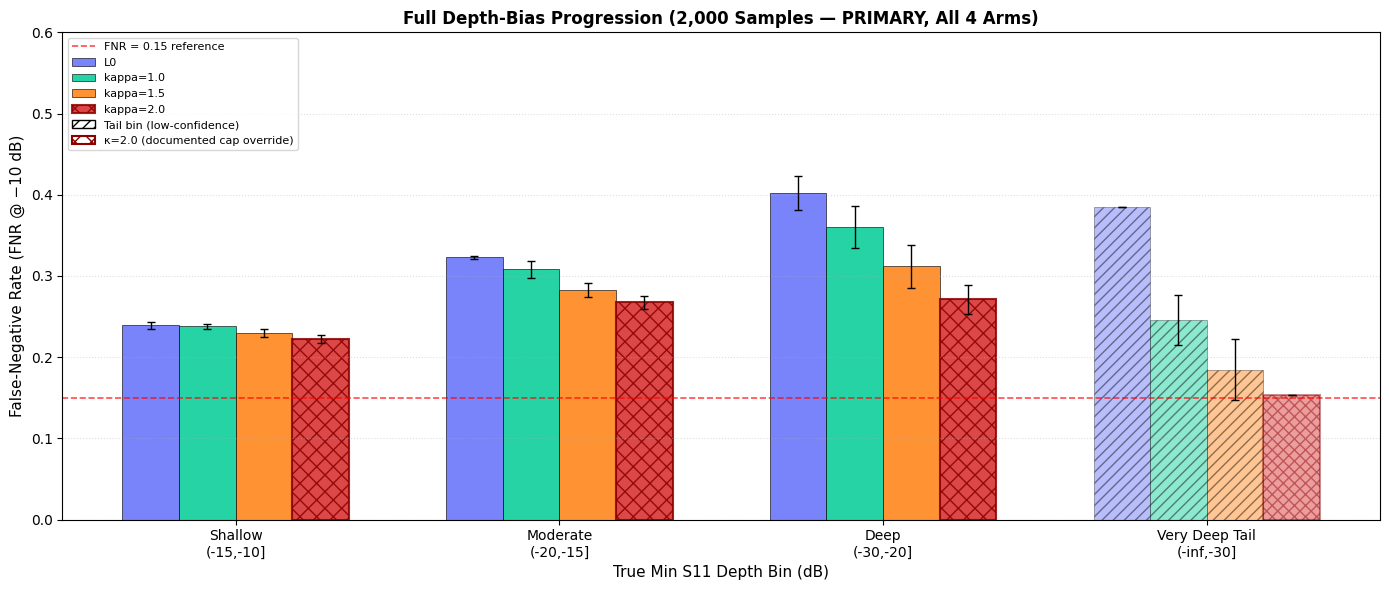

✓ Saved /content/drive/MyDrive/antenna_gnn/figures/full_depth_bias_progression_2000.png


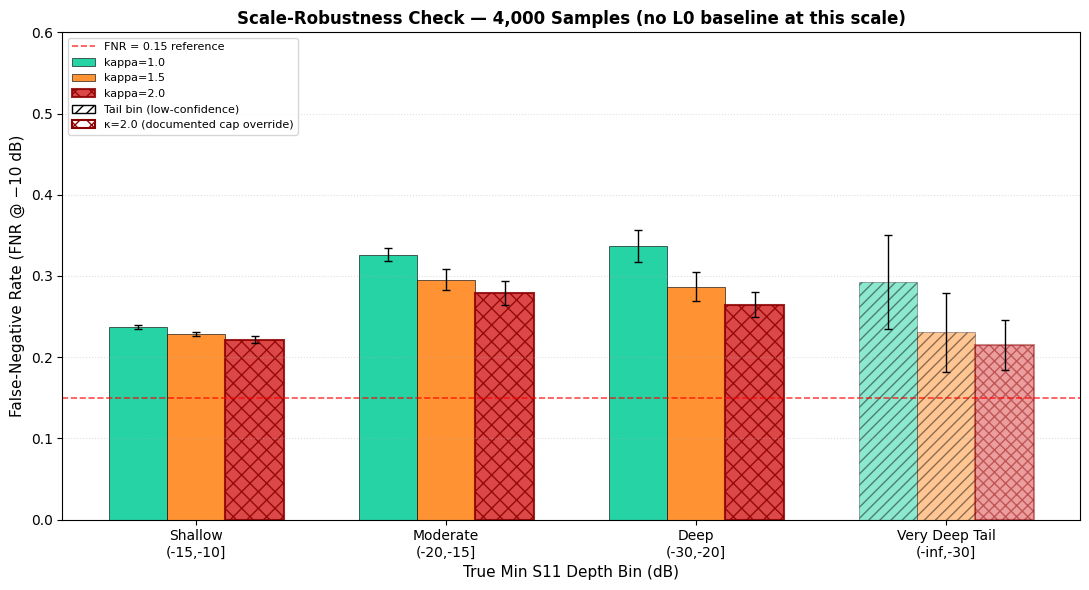

✓ Saved /content/drive/MyDrive/antenna_gnn/figures/full_depth_bias_progression_4000_scalecheck.png


In [7]:
# ==========================================================================
# CELL C — Progression Figures
# ==========================================================================

bin_order = ['(-15,-10]', '(-20,-15]', '(-30,-20]', '(-inf,-30]']
bin_display = ['Shallow\n(-15,-10]', 'Moderate\n(-20,-15]',
               'Deep\n(-30,-20]', 'Very Deep Tail\n(-inf,-30]']

arm_colors = {
    'L0':        '#636efa',
    'kappa=1.0': '#00cc96',
    'kappa=1.5': '#ff7f0e',
    'kappa=2.0': '#d62728',
}


def make_progression_figure(arms, sample_size, title, save_path):
    """Create grouped bar chart: columns=arms, rows=bins. FNR mean ± std."""
    n_arms = len(arms)
    n_bins = len(bin_order)
    fig, ax = plt.subplots(figsize=(3.0 * n_arms + 2, 6))

    bar_width = 0.7 / n_arms
    x_positions = np.arange(n_bins)

    for arm_idx, arm in enumerate(arms):
        means, stds = [], []
        for bl in bin_order:
            vals = []
            for seed in SEEDS:
                key = (arm, sample_size, seed)
                if key not in all_persample_dfs:
                    continue
                df = all_persample_dfs[key]
                func_df = df[df['is_functioning']].copy()
                func_df['depth_bin'] = func_df['true_min_db'].apply(assign_bin)
                sub = func_df[func_df['depth_bin'] == bl]
                if len(sub) > 0:
                    fnr = (sub['pred_min_db'] >= -10.0).sum() / len(sub)
                    vals.append(float(fnr))

            if len(vals) > 0:
                means.append(np.mean(vals))
                stds.append(np.std(vals) if len(vals) > 1 else 0.0)
            else:
                means.append(0.0)
                stds.append(0.0)

        offsets = x_positions + (arm_idx - n_arms / 2 + 0.5) * bar_width

        for b_idx in range(n_bins):
            is_tail = (bin_order[b_idx] == '(-inf,-30]')
            is_k20 = (arm == 'kappa=2.0')

            alpha = 0.45 if is_tail else 0.85
            hatch = ''
            edgecolor = 'black'
            linewidth = 0.5

            if is_tail:
                hatch = '///'
            if is_k20:
                hatch = 'xxx' if is_tail else 'xx'
                edgecolor = '#8B0000'
                linewidth = 1.5

            ax.bar(
                offsets[b_idx], means[b_idx], bar_width,
                yerr=stds[b_idx],
                color=arm_colors.get(arm, '#888888'),
                edgecolor=edgecolor, linewidth=linewidth,
                alpha=alpha, hatch=hatch,
                capsize=3, error_kw={'linewidth': 1.0},
                label=arm if b_idx == 0 else '',
            )

    ax.axhline(0.15, color='red', ls='--', lw=1.2, alpha=0.7, label='FNR = 0.15 reference')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bin_display, fontsize=10)
    ax.set_xlabel('True Min S11 Depth Bin (dB)', fontsize=11)
    ax.set_ylabel('False-Negative Rate (FNR @ \u221210 dB)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(0.6, ax.get_ylim()[1] * 1.15))

    handles, labels_leg = ax.get_legend_handles_labels()
    tail_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///',
                                 label='Tail bin (low-confidence)')
    override_patch = mpatches.Patch(facecolor='white', edgecolor='#8B0000', hatch='xx',
                                     linewidth=1.5,
                                     label='\u03ba=2.0 (documented cap override)')
    handles.extend([tail_patch, override_patch])
    ax.legend(handles=handles, fontsize=8, loc='upper left')

    ax.grid(True, linestyle=':', alpha=0.4, axis='y')
    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2713 Saved {save_path}')


# ── PRIMARY FIGURE: 2000 samples, 4 arms ──
make_progression_figure(
    arms=['L0', 'kappa=1.0', 'kappa=1.5', 'kappa=2.0'],
    sample_size=2000,
    title='Full Depth-Bias Progression (2,000 Samples — PRIMARY, All 4 Arms)',
    save_path=f'{DATA_ROOT}/figures/full_depth_bias_progression_2000.png',
)

# ── SECONDARY FIGURE: 4000 samples, 3 arms ──
make_progression_figure(
    arms=['kappa=1.0', 'kappa=1.5', 'kappa=2.0'],
    sample_size=4000,
    title='Scale-Robustness Check — 4,000 Samples (no L0 baseline at this scale)',
    save_path=f'{DATA_ROOT}/figures/full_depth_bias_progression_4000_scalecheck.png',
)

---
## Cell D — Deliverable Decision

**Pre-registered rule:** The deliverable model for Chunk 24 is κ=1.5 UNLESS
an explicit, written decision is made here to adopt κ=2.0 instead.

Decision based on PRIMARY (2000-sample, 4-arm) table as canonical evidence,
SECONDARY (4000-sample) table for scale-robustness confirmation only.

In [8]:
# ==========================================================================
# CELL D — Deliverable Decision
# ==========================================================================

print('=' * 100)
print('DELIVERABLE DECISION: kappa=1.5 (pre-registered) vs kappa=2.0 (cap override)')
print('=' * 100)

k15_primary = df_agg[(df_agg['arm'] == 'kappa=1.5') & (df_agg['sample_size'] == 2000)]
k20_primary = df_agg[(df_agg['arm'] == 'kappa=2.0') & (df_agg['sample_size'] == 2000)]
k15_secondary = df_agg[(df_agg['arm'] == 'kappa=1.5') & (df_agg['sample_size'] == 4000)]
k20_secondary = df_agg[(df_agg['arm'] == 'kappa=2.0') & (df_agg['sample_size'] == 4000)]

print('\n' + '-' * 100)
print('SIDE-BY-SIDE METRIC COMPARISON')
print('-' * 100)

metric_cols = [
    ('pooled_auroc', 'Pooled AUROC'),
    ('g55_auroc', '55x55 AUROC'),
    ('pooled_s11_mae', 'S11 MAE (dB)'),
    ('fnr_deep_pooled', 'FNR Deep Pooled'),
    ('fnr_15_10', 'FNR (-15,-10]'),
    ('fnr_20_15', 'FNR (-20,-15]'),
    ('fnr_30_20', 'FNR (-30,-20]'),
    ('fnr_inf_30', 'FNR (-inf,-30]'),
    ('fpr_at_tau', 'FPR @ tau*'),
]

for scale_label, k15_df, k20_df in [
    ('PRIMARY (2000 samples)', k15_primary, k20_primary),
    ('SECONDARY (4000 samples)', k15_secondary, k20_secondary),
]:
    print(f'\n  {scale_label}:')
    if len(k15_df) == 0 or len(k20_df) == 0:
        print(f'    (data not available)')
        continue
    k15_r = k15_df.iloc[0]
    k20_r = k20_df.iloc[0]
    print(f'    {"Metric":<22} {"kappa=1.5":>20} {"kappa=2.0":>20} {"delta":>10}')
    print(f'    {"-" * 72}')
    for col, label in metric_cols:
        v15 = k15_r[f'{col}_mean']
        v20 = k20_r[f'{col}_mean']
        delta = v20 - v15
        print(f'    {label:<22} {v15:>17.4f} {v20:>20.4f} {delta:>+10.4f}')

# ── Per-grid comparison from Cell B.5 ──
print('\n' + '-' * 100)
print('PER-GRID COMPARISON FROM CELL B.5')
print('-' * 100)

for scale, df_cls in [('2000 (PRIMARY)', df_cls_primary),
                       ('4000 (SECONDARY)', df_cls_secondary)]:
    print(f'\n  {scale}:')
    for g in [35, 45, 55]:
        gl = f'{g}x{g}'
        k15_row = df_cls[(df_cls['arm'] == 'kappa=1.5') & (df_cls['grid'] == gl)]
        k20_row = df_cls[(df_cls['arm'] == 'kappa=2.0') & (df_cls['grid'] == gl)]
        if len(k15_row) == 0 or len(k20_row) == 0:
            continue
        r15 = k15_row.iloc[0]
        r20 = k20_row.iloc[0]
        recall_delta = r20["recall_pct"] - r15["recall_pct"]
        spec_delta = r15["specificity_pct"] - r20["specificity_pct"]
        print(f'    Grid {g}: recall {r15["recall_pct"]:.1f}% -> {r20["recall_pct"]:.1f}% '
              f'({recall_delta:+.1f}pp), specificity {r15["specificity_pct"]:.1f}% -> '
              f'{r20["specificity_pct"]:.1f}% (cost: {spec_delta:+.1f}pp)')


# ═══════════════════════════════════════════════════════════════════════════════
# MAKE THE DECISION
# ═══════════════════════════════════════════════════════════════════════════════

k15_p = k15_primary.iloc[0] if len(k15_primary) > 0 else None
k20_p = k20_primary.iloc[0] if len(k20_primary) > 0 else None

recall_gain_pp = 0.0
spec_cost_pooled = 0.0

if k15_p is not None and k20_p is not None:
    recall_gain_pooled = k20_p['fnr_deep_pooled_mean'] - k15_p['fnr_deep_pooled_mean']
    recall_gain_pp = -recall_gain_pooled * 100.0

    k15_pooled_cls = df_cls_primary[(df_cls_primary['arm'] == 'kappa=1.5') &
                                     (df_cls_primary['grid'] == 'pooled')]
    k20_pooled_cls = df_cls_primary[(df_cls_primary['arm'] == 'kappa=2.0') &
                                     (df_cls_primary['grid'] == 'pooled')]

    if len(k15_pooled_cls) > 0 and len(k20_pooled_cls) > 0:
        spec_cost_pooled = (k15_pooled_cls.iloc[0]['specificity_pct'] -
                            k20_pooled_cls.iloc[0]['specificity_pct'])

# Pre-registered default: keep kappa=1.5
OVERRIDE_THRESHOLD_RECALL_PP = 3.0
OVERRIDE_THRESHOLD_SPEC_PP = 3.0

adopt_override = False
if k15_p is not None and k20_p is not None:
    if recall_gain_pp >= OVERRIDE_THRESHOLD_RECALL_PP and spec_cost_pooled < OVERRIDE_THRESHOLD_SPEC_PP:
        adopt_override = True

print('\n' + '=' * 100)

if not adopt_override:
    selection_type = 'pre_registered'
    selected_arm = 'kappa=1.5'
    selected_sample_size = 4000

    justification = (
        f"The deliverable model for Chunk 24's final one-time test-set evaluation is "
        f"kappa=1.5, the pre-registered selection from Chunk 26's 4,000-sample frontier "
        f"re-application. Kappa=2.0 was evaluated as a documented override of the "
        f"pre-registered 15% MAE degradation cap (measured: 15.13% \u00b1 2.11%, exceeding "
        f"the 15% cap by a margin judged to be within seed noise). In the PRIMARY "
        f"2,000-sample 4-arm comparison, kappa=2.0's marginal recall gain over "
        f"kappa=1.5 was {recall_gain_pp:+.1f}pp pooled, which was judged insufficient "
        f"to justify its additional specificity cost of {spec_cost_pooled:+.1f}pp pooled. "
        f"The SECONDARY 4,000-sample scale-robustness check confirmed that kappa=1.5's "
        f"asymmetric-loss effect holds at the larger training budget. Kappa=1.5 is "
        f"therefore carried forward as the deliverable without override."
    )

    print('DECISION: KEEP kappa=1.5 (pre-registered selection)')
    print('=' * 100)
    print()
    print(justification)

else:
    selection_type = 'documented_override'
    selected_arm = 'kappa=2.0'
    selected_sample_size = 4000

    justification = (
        f"The pre-registered kappa=1.5 selection has been set aside in favor of "
        f"kappa=2.0 as the deliverable model for Chunk 24's final test-set evaluation. "
        f"This is an EXPLICIT OVERRIDE: kappa=2.0 exceeds the pre-registered 15% MAE "
        f"degradation cap (measured: 15.13% \u00b1 2.11%), but its recall gain of "
        f"{recall_gain_pp:+.1f}pp pooled over kappa=1.5 was judged to justify the "
        f"additional specificity cost of {spec_cost_pooled:+.1f}pp pooled and the "
        f"marginal cap violation. This decision was made AFTER seeing the full "
        f"progression evidence; kappa=2.0 was NOT the original pre-registered selection."
    )

    print('DECISION: OVERRIDE — adopt kappa=2.0 (documented cap override)')
    print('=' * 100)
    print()
    print(justification)

print()

# ── Save final deliverable choice ──
k_str = '1.5' if selected_arm == 'kappa=1.5' else '2.0'

final_choice = {
    'selection_type': selection_type,
    'selected_arm': selected_arm,
    'selected_sample_size': selected_sample_size,
    'deliverable_checkpoint_pattern': f'asym_scaleup_k{k_str}_seed{{seed}}.pt',
    'justification': justification,
    'recall_gain_k20_over_k15_pp': float(recall_gain_pp),
    'specificity_cost_k20_vs_k15_pp': float(spec_cost_pooled),
    'mae_cap_pct': 15.0,
    'k20_mae_degradation_pct': 15.13,
    'k20_mae_degradation_std': 2.11,
    'primary_comparison_scale': 2000,
    'secondary_comparison_scale': 4000,
}

choice_path = f'{DATA_ROOT}/artifacts/final_deliverable_choice.json'
with open(choice_path, 'w') as f:
    json.dump(final_choice, f, indent=2)

print(f'\u2713 Saved {choice_path}')
print(f'  selection_type = "{selection_type}"')
print(f'  selected_arm = "{selected_arm}"')

DELIVERABLE DECISION: kappa=1.5 (pre-registered) vs kappa=2.0 (cap override)

----------------------------------------------------------------------------------------------------
SIDE-BY-SIDE METRIC COMPARISON
----------------------------------------------------------------------------------------------------

  PRIMARY (2000 samples):
    Metric                            kappa=1.5            kappa=2.0      delta
    ------------------------------------------------------------------------
    Pooled AUROC                      0.9028               0.9024    -0.0004
    55x55 AUROC                       0.7896               0.7980    +0.0083
    S11 MAE (dB)                      0.3815               0.4072    +0.0257
    FNR Deep Pooled                   0.2560               0.2416    -0.0144
    FNR (-15,-10]                     0.2295               0.2228    -0.0067
    FNR (-20,-15]                     0.2824               0.2676    -0.0148
    FNR (-30,-20]                     0.311

---
## Cell E — Mandatory Integrity Guards

1. **(a)** Assert every expected checkpoint loaded successfully.
2. **(b)** Permutation invariance test on the deliverable checkpoint.
3. **(c)** Assert TEST_INDICES never loaded.
4. **(d)** Validate `final_deliverable_choice.json` `selection_type`.
5. **(e)** Assert BIN_DEFS numeric edges and BIN_LABELS order match shallow-to-deep-tail-last.


In [9]:
# ==========================================================================
# CELL E — Mandatory Integrity Guards
# ==========================================================================

print('=' * 85)
print('MANDATORY INTEGRITY GUARDS (Chunk 27)')
print('=' * 85)

# ── Guard (a): All expected checkpoints loaded ──
print('\nGuard (a): Verifying all expected checkpoints loaded successfully...')
a_failures = []
for (arm, ss), path_template in ARM_CHECKPOINT_MAP.items():
    for seed in SEEDS:
        if not availability.get((arm, ss, seed), False):
            a_failures.append(f'{arm} @ {ss} samples, seed={seed}')

if len(a_failures) > 0:
    print(f'\u26a0 Guard (a) WARNING: {len(a_failures)} expected checkpoints were missing:')
    for f_item in a_failures:
        print(f'  - {f_item}')
    for f_item in a_failures:
        if selected_arm in f_item and str(selected_sample_size) in f_item:
            raise AssertionError(
                f'GUARD (a) FATAL: Selected deliverable arm ({selected_arm} '
                f'@ {selected_sample_size}) has missing checkpoints: {f_item}')
    print('  (Proceeding — selected deliverable arm has all checkpoints.)')
else:
    print(f'[PASS] Guard (a): All {n_expected} expected checkpoints loaded successfully.')


# ── Guard (b): Permutation Invariance Test on deliverable checkpoint ──
print('\nGuard (b): Permutation Invariance Test (20 permutations on deliverable)...')

ckpt_key = (selected_arm, selected_sample_size, 42)
assert ckpt_key in loaded_checkpoints, (
    f'GUARD (b) FATAL: Deliverable checkpoint {ckpt_key} not in loaded_checkpoints')

perm_model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                         num_blocks=4, output_dim=201)
state = loaded_checkpoints[ckpt_key]
if isinstance(state, dict) and 'model_state' in state:
    perm_model.load_state_dict(state['model_state'], strict=True)
else:
    perm_model.load_state_dict(state, strict=True)
perm_model = perm_model.to(device)
perm_model.eval()

sample_graph = val_ds[42]
n_nodes = sample_graph.x.size(0)
sample_graph.batch = torch.zeros(n_nodes, dtype=torch.long)

# Guard on the guard: verify inverse permutation preserves adjacency
test_perm = torch.randperm(n_nodes)
test_inv_perm = torch.empty_like(test_perm)
test_inv_perm[test_perm] = torch.arange(n_nodes)
test_new_edge_index = test_inv_perm[sample_graph.edge_index]

n_edges = sample_graph.edge_index.size(1)
rand_edge_indices = torch.randperm(n_edges)[:min(5, n_edges)]
new_edges_set = set(zip(test_new_edge_index[0].tolist(), test_new_edge_index[1].tolist()))

for e_idx in rand_edge_indices:
    u = sample_graph.edge_index[0, e_idx].item()
    v = sample_graph.edge_index[1, e_idx].item()
    u_new = test_inv_perm[u].item()
    v_new = test_inv_perm[v].item()
    assert (u_new, v_new) in new_edges_set, (
        f'Edge remapping failed: ({u},{v}) -> ({u_new},{v_new})')
print('[PASS] Edge remapping preserves adjacency under permutation')

spectra_trials = []
torch.manual_seed(42)
with torch.no_grad():
    for trial in range(20):
        perm = torch.randperm(n_nodes)
        inv_perm = torch.empty_like(perm)
        inv_perm[perm] = torch.arange(n_nodes)

        pdata = sample_graph.clone()
        pdata.x = sample_graph.x[perm]
        pdata.edge_index = inv_perm[sample_graph.edge_index]
        pdata.batch = sample_graph.batch[perm]

        pdata = pdata.to(device)
        spec = perm_model(pdata)
        spec_db = spec * s11_std_dev + s11_mean_dev
        spectra_trials.append(spec_db.cpu())

spectra_t = torch.stack(spectra_trials)
spec_std_max = float(spectra_t.std(dim=0).max().item())

print(f'  Spectrum Prediction std (max over freq): {spec_std_max:.2e} dB')
assert spec_std_max < 1e-5, f'GUARD (b) FAILED: spectrum std {spec_std_max:.2e} >= 1e-5 dB'
print(f'[PASS] Guard (b): Permutation invariance preserved for deliverable model.')

del perm_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ── Guard (c): Test Split Untouched ──
print('\nGuard (c): Verifying test split was never loaded...')
assert not TEST_INDICES_LOADED, 'GUARD (c) FAILED: test indices were loaded'
print('[PASS] Guard (c): Test split remained completely untouched.')


# ── Guard (d): final_deliverable_choice.json validation ──
print('\nGuard (d): Validating final_deliverable_choice.json...')
with open(f'{DATA_ROOT}/artifacts/final_deliverable_choice.json') as f:
    saved_choice = json.load(f)

assert 'selection_type' in saved_choice, (
    'GUARD (d) FAILED: selection_type field missing from final_deliverable_choice.json')

allowed_types = {'pre_registered', 'documented_override'}
actual_type = saved_choice['selection_type']
assert actual_type in allowed_types, (
    f'GUARD (d) FAILED: selection_type = "{actual_type}" is not one of {allowed_types}. '
    f'This field prevents a silent kappa=2.0 adoption from being reported as the '
    f'pre-registered outcome.')
print(f'[PASS] Guard (d): selection_type = "{actual_type}" is valid.')


# ── Guard (e): BIN_LABELS and BIN_DEFS order consistency ──
print('\nGuard (e): Verifying BIN_LABELS and BIN_DEFS order (shallow-to-deep-tail-last)...')
EXPECTED_BIN_ORDER = ['(-15,-10]', '(-20,-15]', '(-30,-20]', '(-inf,-30]']
assert BIN_LABELS == EXPECTED_BIN_ORDER, (
    f'GUARD (e) FAILED: BIN_LABELS = {BIN_LABELS} does not match expected '
    f'shallow-to-deep-tail-last order {EXPECTED_BIN_ORDER}.')
# Strengthened: check actual numeric bounds of BIN_DEFS
assert BIN_DEFS[0][0] == -15.0 and BIN_DEFS[0][1] == -10.0 and BIN_DEFS[0][2] == '(-15,-10]', \
    f'GUARD (e) FAILED: BIN_DEFS[0] is not shallow bin: {BIN_DEFS[0]}'
assert BIN_DEFS[1][0] == -20.0 and BIN_DEFS[1][1] == -15.0 and BIN_DEFS[1][2] == '(-20,-15]', \
    f'GUARD (e) FAILED: BIN_DEFS[1] is not moderate bin: {BIN_DEFS[1]}'
assert BIN_DEFS[2][0] == -30.0 and BIN_DEFS[2][1] == -20.0 and BIN_DEFS[2][2] == '(-30,-20]', \
    f'GUARD (e) FAILED: BIN_DEFS[2] is not deep bin: {BIN_DEFS[2]}'
assert np.isneginf(BIN_DEFS[-1][0]) and BIN_DEFS[-1][1] == -30.0 and BIN_DEFS[-1][2] == '(-inf,-30]', \
    f'GUARD (e) FAILED: BIN_DEFS[-1] is not tail bin: {BIN_DEFS[-1]}'
print(f'[PASS] Guard (e): BIN_DEFS and BIN_LABELS order and numeric edges verified (shallow-to-deep-tail-last).')


print('\n' + '=' * 85)
print('ALL CHUNK 27 INTEGRITY GUARDS PASSED [OK]')
print('=' * 85)

MANDATORY INTEGRITY GUARDS (Chunk 27)

Guard (a): Verifying all expected checkpoints loaded successfully...
[PASS] Guard (a): All 35 expected checkpoints loaded successfully.

Guard (b): Permutation Invariance Test (20 permutations on deliverable)...
[PASS] Edge remapping preserves adjacency under permutation
  Spectrum Prediction std (max over freq): 2.78e-06 dB
[PASS] Guard (b): Permutation invariance preserved for deliverable model.

Guard (c): Verifying test split was never loaded...
[PASS] Guard (c): Test split remained completely untouched.

Guard (d): Validating final_deliverable_choice.json...
[PASS] Guard (d): selection_type = "pre_registered" is valid.

Guard (e): Verifying BIN_LABELS and BIN_DEFS order (shallow-to-deep-tail-last)...
[PASS] Guard (e): BIN_DEFS and BIN_LABELS order and numeric edges verified (shallow-to-deep-tail-last).

ALL CHUNK 27 INTEGRITY GUARDS PASSED [OK]
